# Part 1: Data Audit, EDA & Business Understanding

D2C customer churn capstone — snapshot date **2025-09-30**. All behavioral features use data on or before the snapshot only.


In [1]:
import warnings
from pathlib import Path

from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

BASE_DIR = Path('.')
FIG_DIR = BASE_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)
SNAPSHOT = pd.Timestamp('2025-09-30')
print('Working directory:', BASE_DIR.resolve())
print('Snapshot date:', SNAPSHOT.date())


Working directory: C:\Users\Keshav Verma\onediveNew\OneDrive\Desktop\TechStack\ALML\capstone project\part 1
Snapshot date: 2025-09-30


## Phase 1: Load & Inspect Raw Data


In [2]:
customers = pd.read_csv(BASE_DIR / 'customers.csv', parse_dates=['signup_date'])
orders = pd.read_csv(BASE_DIR / 'orders.csv', parse_dates=['order_date'])
support_tickets = pd.read_csv(BASE_DIR / 'support_tickets.csv', parse_dates=['ticket_date'])
web_events = pd.read_csv(BASE_DIR / 'web_events_snapshot.csv', parse_dates=['snapshot_date'])
churn_labels = pd.read_csv(BASE_DIR / 'churn_labels.csv', parse_dates=['snapshot_date'])
intervention_history = pd.read_csv(BASE_DIR / 'intervention_history.csv', parse_dates=['snapshot_date'])

datasets = {
    'customers': customers,
    'orders': orders,
    'support_tickets': support_tickets,
    'web_events_snapshot': web_events,
    'churn_labels': churn_labels,
    'intervention_history': intervention_history,
}

for name, df in datasets.items():
    print(f'\n=== {name} ===')
    print('shape:', df.shape)
    print('dtypes:\n', df.dtypes)
    display(df.head(2))



=== customers ===
shape: (2400, 9)
dtypes:
 customer_id                    object
signup_date            datetime64[ns]
city_tier                      object
age_group                      object
acquisition_channel            object
loyalty_tier                   object
preferred_category             object
skin_type                      object
marketing_consent              object
dtype: object


,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes



=== orders ===
shape: (10009, 10)
dtypes:
 order_id                 object
customer_id              object
order_date       datetime64[ns]
category                 object
quantity                  int64
gross_amount            float64
discount_pct            float64
delivery_days             int64
returned                  int64
rating                  float64
dtype: object


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0



=== support_tickets ===
shape: (1921, 8)
dtypes:
 ticket_id                   object
customer_id                 object
ticket_date         datetime64[ns]
issue_type                  object
support_channel             object
resolution_hours           float64
sentiment_score            float64
reopened                     int64
dtype: object


...

,customer_id,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,2025-09-30,1,4,0,0,0,2,0,20
1,CUST00002,2025-09-30,8,31,4,2,3,0,0,0



=== churn_labels ===
shape: (2400, 4)
dtypes:
 customer_id               object
snapshot_date     datetime64[ns]
churn_next_60d             int64
split                     object
dtype: object


,customer_id,snapshot_date,churn_next_60d,split
0,CUST00001,2025-09-30,1,train
1,CUST00002,2025-09-30,0,train



=== intervention_history ===
shape: (2400, 5)
dtypes:
 customer_id                       object
snapshot_date             datetime64[ns]
last_campaign_received            object
last_campaign_cost                 int64
manual_priority_bucket            object
dtype: object


,customer_id,snapshot_date,last_campaign_received,last_campaign_cost,manual_priority_bucket
0,CUST00001,2025-09-30,welcome_offer,25,high
1,CUST00002,2025-09-30,free_shipping,12,medium


In [3]:
orders_pre = orders[orders['order_date'] <= SNAPSHOT].copy()
tickets_pre = support_tickets[support_tickets['ticket_date'] <= SNAPSHOT].copy()

print(f'orders total: {len(orders):,} | pre-snapshot: {len(orders_pre):,} | post-snapshot (label only): {len(orders) - len(orders_pre):,}')
print(f'tickets total: {len(support_tickets):,} | pre-snapshot: {len(tickets_pre):,}')
assert customers['customer_id'].nunique() == 2400
assert churn_labels['customer_id'].nunique() == 2400


orders total: 10,009 | pre-snapshot: 8,137 | post-snapshot (label only): 1,872
tickets total: 1,921 | pre-snapshot: 1,921


In [4]:
join_checks = []
for name, df in [
    ('churn_labels', churn_labels),
    ('web_events_snapshot', web_events),
    ('intervention_history', intervention_history),
]:
    merged = customers.merge(df, on='customer_id', how='left', suffixes=('', '_r'))
    join_checks.append({
        'dataset': name,
        'rows_after_left_join': len(merged),
        'customers_unmatched': merged['customer_id'].isna().sum() if 'customer_id' in merged else 0,
        'duplicate_customer_id_in_right': df['customer_id'].duplicated().sum(),
    })

# orders & tickets are one-to-many
orders_customers = orders_pre['customer_id'].nunique()
tickets_customers = tickets_pre['customer_id'].nunique()
join_checks.append({'dataset': 'orders_pre (distinct customers)', 'rows_after_left_join': orders_customers, 'customers_unmatched': 0, 'duplicate_customer_id_in_right': 'N/A'})
join_checks.append({'dataset': 'tickets_pre (distinct customers)', 'rows_after_left_join': tickets_customers, 'customers_unmatched': 0, 'duplicate_customer_id_in_right': 'N/A'})

join_summary = pd.DataFrame(join_checks)
display(join_summary)
print('All 2,400 customers retained on left joins to one-row-per-customer tables.')


,dataset,rows_after_left_join,customers_unmatched,duplicate_customer_id_in_right
0,churn_labels,2400,0,0
1,web_events_snapshot,2400,0,0
2,intervention_history,2400,0,0
3,orders_pre (distinct customers),2400,0,N/A
4,tickets_pre (distinct customers),1247,0,N/A


All 2,400 customers retained on left joins to one-row-per-customer tables.


## Phase 2: Data Quality Audit


In [5]:
def missing_summary(df, name):
    pct = (df.isnull().mean() * 100).round(2)
    out = pct[pct > 0].reset_index()
    out.columns = ['column', 'missing_pct']
    out['dataset'] = name
    return out

missing_parts = [missing_summary(df, n) for n, df in datasets.items() if df.isnull().any().any()]
missing_table = pd.concat(missing_parts, ignore_index=True)
display(missing_table.sort_values(['dataset', 'missing_pct'], ascending=[True, False]))


,column,missing_pct,dataset
0,loyalty_tier,57.75,customers
1,skin_type,16.71,customers
2,rating,0.80,orders


In [6]:
dup_orders_suffix = orders['order_id'].astype(str).str.endswith('_DUP').sum()
dup_order_ids = orders['order_id'].duplicated().sum()
dup_customers = customers['customer_id'].duplicated().sum()

q1, q3 = orders_pre['gross_amount'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = orders_pre[(orders_pre['gross_amount'] < lower) | (orders_pre['gross_amount'] > upper)]

post_snapshot_orders = (orders['order_date'] > SNAPSHOT).sum()
future_tickets = (support_tickets['ticket_date'] > SNAPSHOT).sum()

quality_findings = pd.DataFrame([
    {'check': 'Duplicate customer_id in customers', 'result': dup_customers},
    {'check': 'Duplicate order_id values', 'result': dup_order_ids},
    {'check': 'order_id ending with _DUP', 'result': dup_orders_suffix},
    {'check': 'IQR outliers in gross_amount (pre-snapshot)', 'result': len(outliers)},
    {'check': 'Post-snapshot orders (must not be features)', 'result': post_snapshot_orders},
    {'check': 'Tickets after snapshot', 'result': future_tickets},
    {'check': 'Missing ratings in orders_pre', 'result': orders_pre['rating'].isnull().sum()},
])

display(quality_findings)
print('Sample _DUP orders:')
display(orders[orders['order_id'].astype(str).str.endswith('_DUP')].head())
print('Sample gross_amount outliers:')
display(outliers.nlargest(5, 'gross_amount')[['order_id', 'customer_id', 'order_date', 'gross_amount']])


,check,result
0,Duplicate customer_id in customers,0
1,Duplicate order_id values,0
2,order_id ending with _DUP,12
3,IQR outliers in gross_amount (pre-snapshot),429
4,Post-snapshot orders (must not be features),1872
5,Tickets after snapshot,0
6,Missing ratings in orders_pre,58


Sample _DUP orders:


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
601,ORD008249_DUP,CUST00153,2025-11-04,Hair Care,1,321.31,0.36,8,0,3.0
2621,ORD002124_DUP,CUST00628,2025-03-18,Skin Care,1,410.04,0.47,3,0,5.0
3534,ORD002862_DUP,CUST00837,2025-07-12,Hair Care,3,952.02,0.47,4,0,4.0
3602,ORD002916_DUP,CUST00848,2025-09-26,Skin Care,1,547.18,0.28,2,0,5.0
3675,ORD002970_DUP,CUST00869,2024-12-22,Fragrance,1,818.64,0.18,2,0,4.0


Sample gross_amount outliers:


,order_id,customer_id,order_date,gross_amount
7810,ORD006374,CUST01868,2025-03-29,24789.38
874,ORD000701,CUST00211,2024-11-27,22719.45
8836,ORD007206,CUST02106,2024-07-13,15957.48
5450,ORD004428,CUST01295,2025-05-01,10643.82
5721,ORD004650,CUST01360,2024-10-09,8777.20


In [7]:
leakage_columns = pd.DataFrame([
    {'source': 'churn_labels.csv', 'column': 'churn_next_60d', 'risk': 'Target — never use as a feature'},
    {'source': 'orders.csv', 'column': 'order_date > 2025-09-30', 'risk': 'Post-snapshot rows — exclude from feature engineering'},
    {'source': 'churn_labels.csv', 'column': 'split', 'risk': 'Use only for train/val/test assignment, not as a feature'},
])
display(leakage_columns)
print('Feature rule: aggregate orders, tickets, and web metrics only through', SNAPSHOT.date())


,source,column,risk
0,churn_labels.csv,churn_next_60d,Target — never use as a feature
1,orders.csv,order_date > 2025-09-30,Post-snapshot rows — exclude from feature engi...
2,churn_labels.csv,split,"Use only for train/val/test assignment, not as..."


Feature rule: aggregate orders, tickets, and web metrics only through 2025-09-30


## Phase 3: Exploratory Data Analysis (6 charts)

All charts use pre-snapshot behavioral data joined to churn_next_60d.


In [8]:
analysis_base = customers.merge(
    churn_labels[['customer_id', 'churn_next_60d', 'split']],
    on='customer_id',
    how='left',
)
analysis_base = analysis_base.merge(web_events, on='customer_id', how='left')

last_order_date = orders_pre.groupby('customer_id')['order_date'].max().reset_index()
last_order_date['recency_days'] = (SNAPSHOT - last_order_date['order_date']).dt.days
analysis_base = analysis_base.merge(last_order_date[['customer_id', 'recency_days']], on='customer_id', how='left')
analysis_base['recency_days'] = analysis_base['recency_days'].fillna(999)

order_agg = orders_pre.groupby('customer_id').agg(
    order_count=('order_id', 'count'),
    return_rate=('returned', 'mean'),
    avg_discount=('discount_pct', 'mean'),
).reset_index()
analysis_base = analysis_base.merge(order_agg, on='customer_id', how='left')
analysis_base['return_rate'] = analysis_base['return_rate'].fillna(0)
analysis_base['order_count'] = analysis_base['order_count'].fillna(0)

churn_pct = analysis_base['churn_next_60d'].mean() * 100
print(f'Overall 60-day churn rate: {churn_pct:.1f}% (n={len(analysis_base):,})')


Overall 60-day churn rate: 47.0% (n=2,400)


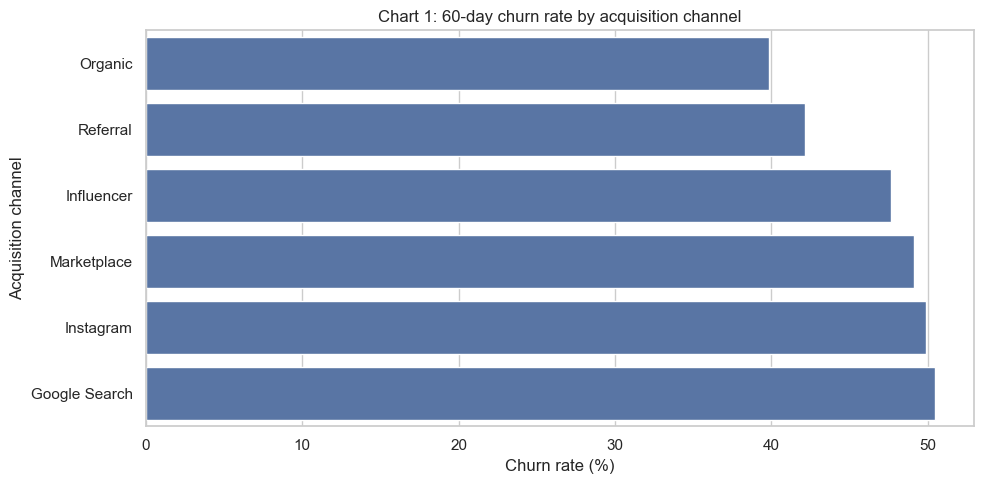

Takeaway: Google Search and Instagram (~50%) churn highest; Organic and Referral lowest (~40–42%).


In [9]:
# Chart 1: Churn rate by acquisition channel
channel_churn = analysis_base.groupby('acquisition_channel', as_index=False).agg(
    churn_rate=('churn_next_60d', 'mean'),
    customers=('churn_next_60d', 'count'),
)
channel_churn['churn_rate_pct'] = channel_churn['churn_rate'] * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=channel_churn.sort_values('churn_rate_pct'), x='churn_rate_pct', y='acquisition_channel', ax=ax, color='#4C72B0')
ax.set_xlabel('Churn rate (%)')
ax.set_ylabel('Acquisition channel')
ax.set_title('Chart 1: 60-day churn rate by acquisition channel')
plt.tight_layout()
plt.savefig(FIG_DIR / '01_churn_by_channel.png', bbox_inches='tight')
plt.show()
print('Takeaway: Google Search and Instagram (~50%) churn highest; Organic and Referral lowest (~40–42%).')


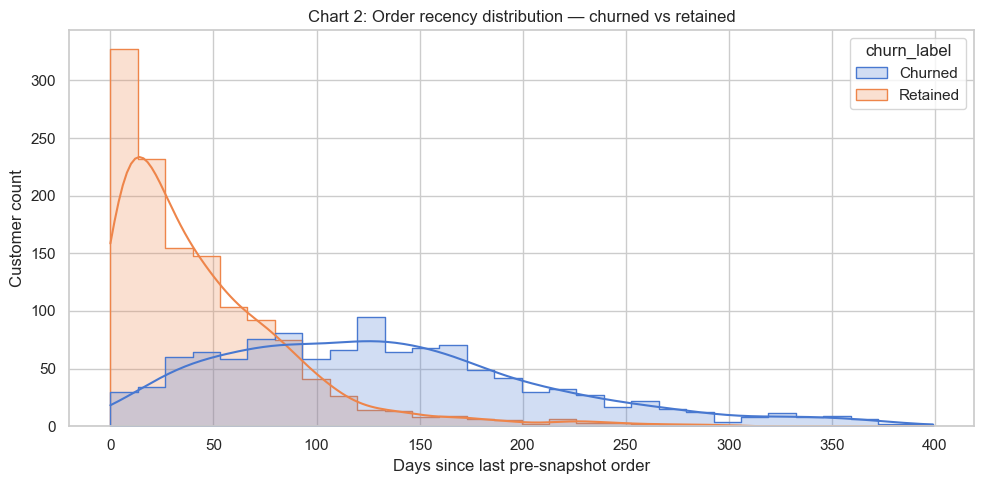

Takeaway: Customers with recency >60 days show ~72% churn vs ~12% for recency ≤30 days.


In [10]:
# Chart 2: Recency distribution by churn status
plot_recency = analysis_base[analysis_base['recency_days'] < 400].copy()
plot_recency['churn_label'] = plot_recency['churn_next_60d'].map({0: 'Retained', 1: 'Churned'})

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=plot_recency, x='recency_days', hue='churn_label', bins=30, kde=True, element='step', ax=ax)
ax.set_xlabel('Days since last pre-snapshot order')
ax.set_ylabel('Customer count')
ax.set_title('Chart 2: Order recency distribution — churned vs retained')
plt.tight_layout()
plt.savefig(FIG_DIR / '02_recency_by_churn.png', bbox_inches='tight')
plt.show()
print('Takeaway: Customers with recency >60 days show ~72% churn vs ~12% for recency ≤30 days.')


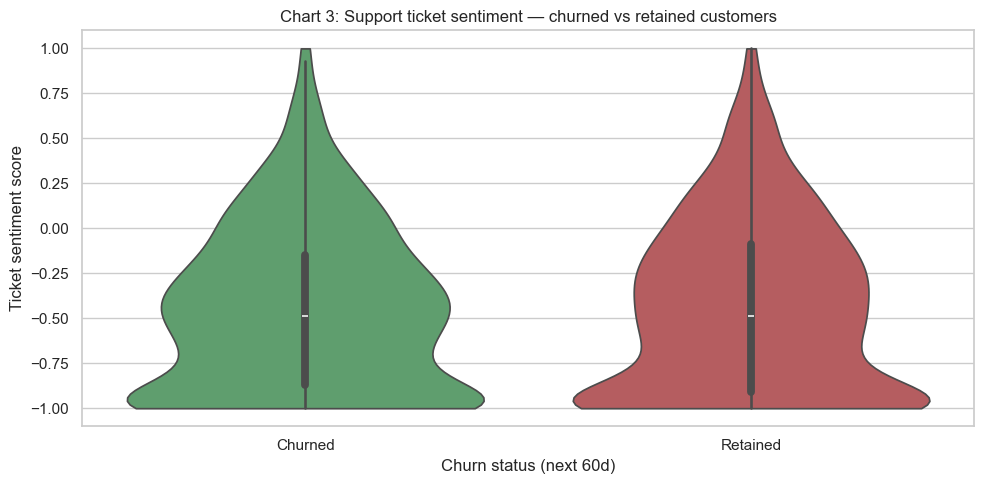

Takeaway: Both groups skew negative; customers with ≥3 tickets churn ~35% vs ~47% with no tickets.


In [11]:
# Chart 3: Ticket sentiment by churn (customers with tickets)
tickets_labeled = tickets_pre.merge(churn_labels[['customer_id', 'churn_next_60d']], on='customer_id')
tickets_labeled['churn_label'] = tickets_labeled['churn_next_60d'].map({0: 'Retained', 1: 'Churned'})

fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(data=tickets_labeled, x='churn_label', y='sentiment_score', cut=0, ax=ax, palette=['#55A868', '#C44E52'])
ax.set_xlabel('Churn status (next 60d)')
ax.set_ylabel('Ticket sentiment score')
ax.set_title('Chart 3: Support ticket sentiment — churned vs retained customers')
plt.tight_layout()
plt.savefig(FIG_DIR / '03_sentiment_by_churn.png', bbox_inches='tight')
plt.show()
print('Takeaway: Both groups skew negative; customers with ≥3 tickets churn ~35% vs ~47% with no tickets.')


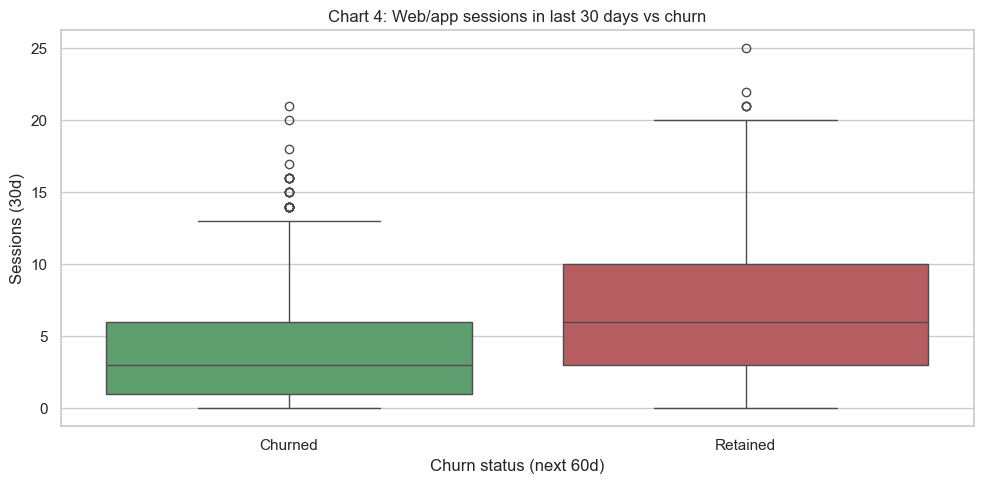

Takeaway: Median sessions 6 for retained vs 3 for churned; 11.2% of churned had zero sessions vs 5.0% retained.


In [12]:
# Chart 4: Web sessions in last 30 days
analysis_base['churn_label'] = analysis_base['churn_next_60d'].map({0: 'Retained', 1: 'Churned'})

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=analysis_base, x='churn_label', y='sessions_30d', ax=ax, palette=['#55A868', '#C44E52'])
ax.set_xlabel('Churn status (next 60d)')
ax.set_ylabel('Sessions (30d)')
ax.set_title('Chart 4: Web/app sessions in last 30 days vs churn')
plt.tight_layout()
plt.savefig(FIG_DIR / '04_sessions_by_churn.png', bbox_inches='tight')
plt.show()
print('Takeaway: Median sessions 6 for retained vs 3 for churned; 11.2% of churned had zero sessions vs 5.0% retained.')


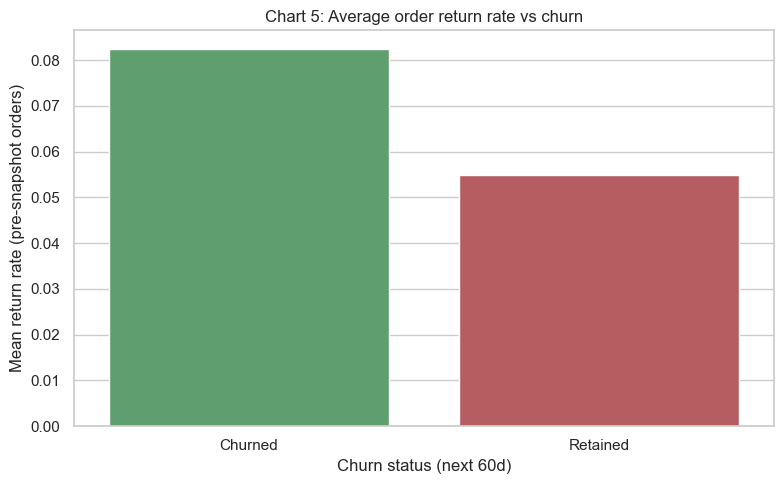

Takeaway: Churned customers average 8.2% return rate vs 5.5% for retained (+2.7 pp).


In [13]:
# Chart 5: Return rate by churn status
fig, ax = plt.subplots(figsize=(8, 5))
return_by_churn = analysis_base.groupby('churn_label')['return_rate'].mean().reset_index()
sns.barplot(data=return_by_churn, x='churn_label', y='return_rate', ax=ax, palette=['#55A868', '#C44E52'])
ax.set_ylabel('Mean return rate (pre-snapshot orders)')
ax.set_xlabel('Churn status (next 60d)')
ax.set_title('Chart 5: Average order return rate vs churn')
plt.tight_layout()
plt.savefig(FIG_DIR / '05_return_rate_by_churn.png', bbox_inches='tight')
plt.show()
print('Takeaway: Churned customers average 8.2% return rate vs 5.5% for retained (+2.7 pp).')


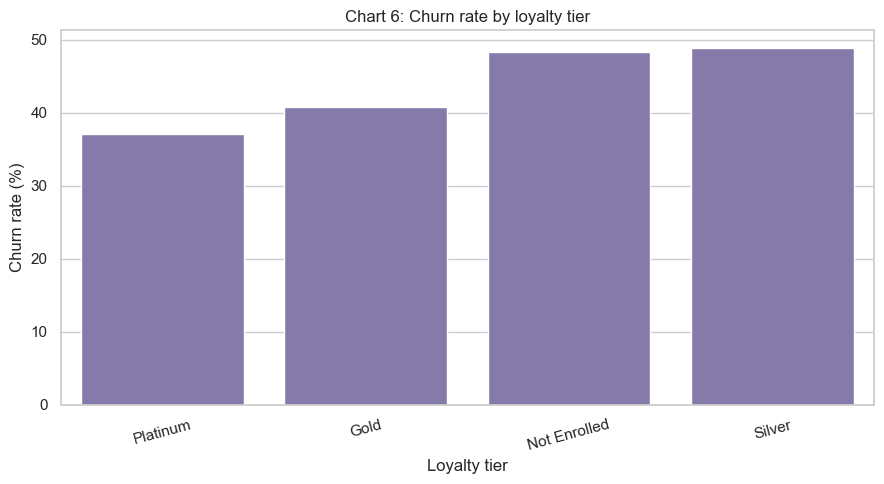

Takeaway: Silver and not-enrolled tiers ~48–49% churn; Platinum lowest at ~37%.


In [14]:
# Chart 6: Churn rate by loyalty tier
loyalty_df = analysis_base.copy()
loyalty_df['loyalty_tier'] = loyalty_df['loyalty_tier'].fillna('Not Enrolled')
loyalty_churn = loyalty_df.groupby('loyalty_tier', as_index=False).agg(
    churn_rate=('churn_next_60d', 'mean'), n=('churn_next_60d', 'count')
)
loyalty_churn['churn_rate_pct'] = loyalty_churn['churn_rate'] * 100

fig, ax = plt.subplots(figsize=(9, 5))
order_loy = loyalty_churn.sort_values('churn_rate_pct')
sns.barplot(data=order_loy, x='loyalty_tier', y='churn_rate_pct', ax=ax, color='#8172B2')
ax.set_ylabel('Churn rate (%)')
ax.set_xlabel('Loyalty tier')
ax.set_title('Chart 6: Churn rate by loyalty tier')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIG_DIR / '06_loyalty_churn.png', bbox_inches='tight')
plt.show()
print('Takeaway: Silver and not-enrolled tiers ~48–49% churn; Platinum lowest at ~37%.')


## Phase 4: Five churn-risk hypotheses (evidence-based)


### Hypothesis 1: Long order recency predicts churn
- **Evidence:** Chart 2 (recency histogram); recency bucket table in notebook output
- **Pattern:** Customers with recency >60 days have **72.3%** churn (n=1,260) vs **11.7%** when last order was within 30 days (n=699).
- **Business implication:** Win-back outreach should prioritize customers who have not purchased in 60+ days before broad discounting.

### Hypothesis 2: Low digital engagement signals churn
- **Evidence:** Chart 4 (sessions boxplot); zero-session rates
- **Pattern:** Churned customers median **3** sessions vs **6** for retained; **11.2%** of churned had zero sessions vs **5.0%** retained. last_visit_days_ago ≥30 associates with **87.8%** churn (n=516).
- **Business implication:** Re-engagement pushes (email/app) should target low-session and long-absence visitors before blanket offers.

### Hypothesis 3: Paid-search and social acquisition channels churn more
- **Evidence:** Chart 1 (churn by acquisition channel)
- **Pattern:** Google Search (**50.4%**) and Instagram (**49.9%**) show highest churn; Organic (**39.8%**) and Referral (**42.2%**) lowest.
- **Business implication:** Investigate onboarding quality and first-90-day experience for paid/social cohorts separately from organic/referral.

### Hypothesis 4: Higher returns and service friction relate to churn
- **Evidence:** Chart 5 (return rate); ticket volume analysis
- **Pattern:** Mean return rate **8.2%** (churned) vs **5.5%** (retained). Customers with **≥3** pre-snapshot tickets show **34.9%** churn vs **47.2%** with no tickets — heavy complainers may still be engaged if resolved well.
- **Business implication:** Pair retention offers with logistics/quality fixes for high-return customers; do not treat all ticket volume as equal risk.

### Hypothesis 5: Loyalty enrollment alone does not protect Silver-tier customers
- **Evidence:** Chart 6 (loyalty vs churn)
- **Pattern:** Silver tier churn **48.8%** (n=590), close to not-enrolled **48.3%** (n=1,386); Platinum **37.1%** (n=105).
- **Business implication:** Upgrade Silver customers with personalized benefits rather than assuming enrollment reduces churn.


In [15]:
# Supplementary table: recency buckets vs churn
recency_bins = [0, 30, 60, 120, 9999]
recency_labels = ['0-30 days', '31-60', '61-120', '121+ / no order']
analysis_base['recency_bucket'] = pd.cut(analysis_base['recency_days'], bins=recency_bins, labels=recency_labels, right=True)
recency_table = analysis_base.groupby('recency_bucket', observed=False)['churn_next_60d'].agg(['mean', 'count'])
recency_table['churn_rate_pct'] = (recency_table['mean'] * 100).round(1)
display(recency_table)


,mean,count,churn_rate_pct
recency_bucket,,,
0-30 days,0.119225,671,11.9
31-60,0.303855,441,30.4
61-120,0.534454,595,53.4
121+ / no order,0.891729,665,89.2
